# 🧬 Cuaderno 05 - Secuencias y k-mers

**Curso:**: Bioinformática
**Tema:**: Secuencias y k-mers
**Repositorio:**: `bio-notebooks`
**Herramientas:**: Python, Jupyter Notebook, Biopython

## Competencias del curso y del laboratorio
- Implementar algoritmos de alineamiento de secuencias global utilizando programación dinámica.
- Desarrollar algoritmos eficientes para el conteo y análisis de k-mers en secuencias biológicas, identificando patrones y visualizando información genómica.
- Aplicar conceptos fundamentales de la Bioinformática para analizar similitud entre secuencias biológicas y extraer información relevante de datos genómicos.
- Utilizar herramientas y bibliotecas de Python, como Biopython, para manipular y analizar secuencias biológicas, facilitando la interpretación de datos genómicos y la visualización de resultados.

## Contenido
1. Marco teórico
2. Implementación de algoritmos de conteo de k-mers
3. Análisis de frecuencias de k-mers en secuencias biológicas
4. Visualización de resultados y patrones de k-mers
5. Aplicaciones prácticas en genómica y metagenómica

## 1. Marco teórico
En esta sección se introduce el concepto de k-mers, su importancia en el análisis genómico y las aplicaciones prácticas en bioinformática. Se discuten las técnicas de conteo de k-mers, las estructuras de datos utilizadas para su almacenamiento y los desafíos computacionales asociados con el análisis de k-mers en grandes conjuntos de datos genómicos.

Los k-mers son subsecuencias contiguas de longitud k extraídas a partir de una secuencia biológica, ya sea ADN, ARN o proteínas. El análisis de k-mers constituye una de las técnicas fundamentales para el procesamiento y estudio de información genómica debido a su eficiencia computacional y su capacidad para identificar patrones biológicos relevantes.

Dada una secuencia de longitud n, el número total de k-mers que pueden extraerse se calcula mediante:
n − k + 1

Por ejemplo, para la secuencia ATGCA y k = 3, los k-mers obtenidos son:
- ATG
- TGC
- GCA

En secuencias de ADN existen cuatro nucleótidos posibles (A,T,C,G), por lo que el número total de combinaciones posibles de k-mers está dado por 4^k.

El análisis de frecuencias de k-mers permite identificar regiones repetitivas, patrones evolutivos y similitudes entre organismos. Además, constituye la base de múltiples aplicaciones modernas, incluyendo:
- ensamblaje de genomas
- alineamiento de secuencias
- metagenómica
- detección de mutaciones
- clasificación taxonómica
- búsqueda de similitud genética

Desde el punto de vista computacional, el conteo de k-mers requiere algoritmos eficientes debido al gran volumen de datos genómicos. Para ello, suelen emplearse estructuras de datos como tablas hash, diccionarios y árboles Trie, así como técnicas de optimización mediante ventanas deslizantes (sliding window) y paralelización.

En aplicaciones reales, los valores de k suelen variar entre 3 y 31 dependiendo del objetivo del análisis. Valores pequeños permiten detectar patrones generales, mientras que valores grandes ofrecen mayor especificidad genética, aunque incrementan el costo computacional y el uso de memoria.

### Funciones necesarias para el análisis de k-mers

Para llevar a cabo el análisis de k-mers, es necesario implementar funciones que permitan:
1. Descargar secuencias biológicas desde bases de datos como NCBI utilizando Biopython.
2. Leer secuencias desde archivos FASTA para su posterior análisis.

In [1]:
from Bio import Entrez, SeqIO
import os
from typing import Tuple, Optional

# Configuramos tnuestro email (NCBI exige un email valido)
# Entrez.email = "miemail@example.com"
# Si tenemos api_key (opcional), usamos: Entrez.api_key = "TU_API_KEY"

def fetch_fasta_from_ncbi(accession: str, email: str, save_path: Optional[str] = None, db: str = "nucleotide") -> Tuple[str, str, str]:
    """
    Descargamso un registro FASTA desde NCBI usando Biopython Entrez y nos devuelve (id, descripcion, secuencia).
    Si proporcioanmos save_path , guardamos el archivo FASTA en esa ruta
    Parametros:
      - accession: ID o accesión (por ejemplo 'NM_000518.5' o 'U14680.1')
      - email: el email es obligatorio para usar Entrez (NCBI)
      - save_path: si no usamos None, se guarda el archivo FASTA en la ruta uqe ponemos
      - db: 'nucleotide' o 'protein' según corresponda
    Retorna:
      (record.id, record.description, str(record.seq))
    """
    Entrez.email = email
    handle = None
    try:
        handle = Entrez.efetch(db=db, id=accession, rettype="fasta", retmode="text")
        # Parseamos con SeqIO para devolver valores consistentes
        record = SeqIO.read(handle, "fasta")
        seq_id = record.id
        desc = record.description
        seq = str(record.seq)
    finally:
        if handle is not None:
            handle.close()

    if save_path:
        # Nos aseguramos de que el directorio existe
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        # Escribimos el archio FASTA (usando SeqIO para formateo correcto)
        with open(save_path, "w") as outfh:
            SeqIO.write(record, outfh, "fasta")

    return seq_id, desc, seq

In [2]:
#Leer fasta
def leer_fasta(filepath: str) -> tuple[str, str, str]:
    """Leemos un archivo FASTA y nos devuelve el ID, la descripción y la secuencia
    Argumentos:
        filepath (str): Es la ruta al archivo FASTA

    Retorna:
        tuple[str, str, str]: ID, descripción y secuencia
    """
    with open(filepath, 'r') as file:
        lineas = file.readlines()
    header = lineas[0].strip()
    #print("header: ",header)
    #print("header.split(): ",header.split())
    secuencia_id = header.split()[0][1:]  # Eliminar el '>' y obtener el ID
    descripcion = ' '.join(header.split()[1:])  # Obtener la descripción
    secuencia = ''.join(linea.strip() for linea in lineas[1:]).upper()  # Unir las líneas de la secuencia
    return secuencia_id, descripcion, secuencia

In [3]:
from dataclasses import dataclass
from concurrent.futures import ThreadPoolExecutor

#Dataclass nos genera automaticamente nuestro constructor
# Crea constrcutor -> __init__(),
# Genera automaticamente la impresion de datos para desarroladores -> __repr()__
# Podemos sobrecargar apra personalizar repr
#print prioriza str a repr, por eso si queremos personalizar la impresión para usuarios finales, sobrecargamos __str__() y si queremos personalizar la impresión para desarrolladores (debugging), sobrecargamos __repr__()
# property se usa como atributo no como metodo
@dataclass
class Secuencia:
    id: str
    descripcion: str
    secuencia: str

    @property
    def longitud(self) -> int:
        return len(self.secuencia)

    def __str__(self) -> str:
        """Sobrecargamos __str__ para usuarios finales (cuando hacemos print())"""
        return (f" Secuencia: {self.id}\n"
                f" Longitud: {self.longitud} pb\n"
                f" Descripción: {self.descripcion[:70]}...\n"
                f" Primeros 40 pb: {self.secuencia[:40]}...")

    def __repr__(self) -> str:
        """Sobrecargamos __repr__ para desarrolladores (debugging en consola)"""
        muestra_seq = self.secuencia[:60] + "..." if len(self.secuencia) > 60 else self.secuencia
        return (f"Secuencia(id='{self.id}', longitud={self.longitud}, "
                f"desc='{self.descripcion[:50]}...', seq='{muestra_seq}')")

## 2. Implementación de algoritmos de conteo de k-mers
En esta sección se implementan algoritmos para el conteo de k-mers en secuencias biológicas utilizando Python. Se presentan diferentes enfoques, incluyendo el uso de diccionarios para almacenar las frecuencias de k-mers y técnicas de optimización para mejorar la eficiencia del conteo. Además, se discuten las ventajas y desventajas de cada método, así como su aplicabilidad en diferentes contextos genómicos.

### 2.1. Descarfa de secuencias desde NCBI utilizando Biopython
En esta subsección muestro cómo descargar secuencias biológicas desde la base de datos NCBI utilizando la biblioteca Biopython. Se implementa una función que permite obtener secuencias en formato FASTA a partir de un ID de acceso, facilitando su posterior análisis de k-mers. Además, se discuten las consideraciones importantes al interactuar con la API de NCBI, como la gestión de solicitudes y el manejo de errores.

In [4]:
#Lista de accsession
# NM_000518.5, NM_009764
lista_accession = ["NM_000518.5", "NM_009764", "NC_000913.2", "NC_003197.2"]

#Ejemplo de uso de la función fetch_fasta_from_ncbi
path = "data/"
email = "rhyi888@gmail.com"  # Reemplazamos con nuestro email
for accession in lista_accession:
    save_path = path + accession + ".fasta"  # Guardamos cada secuencia con su accession como nombre de archivo
    seq_id, desc, seq = fetch_fasta_from_ncbi(accession=accession, email=email, save_path=save_path)
    # Descargamos la secuencia y la guardamos en un archivo FASTA
    print(f"Accession: {accession}")
    print(f"ID: {seq_id}")
    print(f"Descripción: {desc}")
    print(f"Secuencia: {seq[:50]}...")  # Imprimimos solo los primeros 50 caracteres de la secuencia para evitar saturar la salida

Accession: NM_000518.5
ID: NM_000518.5
Descripción: NM_000518.5 Homo sapiens hemoglobin subunit beta (HBB), mRNA
Secuencia: ACATTTGCTTCTGACACAACTGTGTTCACTAGCAACCTCAAACAGACACC...
Accession: NM_009764
ID: NM_009764.3
Descripción: NM_009764.3 Mus musculus breast cancer 1, early onset (Brca1), mRNA
Secuencia: GTTCCGAAAGGCTAGCGCTAGGCGCCAAGCGGCCGGTTTCCTTGGCGACG...
Accession: NC_000913.2
ID: NC_000913.2
Descripción: NC_000913.2 Escherichia coli str. K-12 substr. MG1655, complete genome
Secuencia: AGCTTTTCATTCTGACTGCAACGGGCAATATGTCTCTGTGTGGATTAAAA...
Accession: NC_003197.2
ID: NC_003197.2
Descripción: NC_003197.2 Salmonella enterica subsp. enterica serovar Typhimurium str. LT2, complete genome
Secuencia: AGAGATTACGTCTGGTTGCAAGAGATCATGACAGGGGGAATTGGTTGAAA...


### 2.2. Lectura de secuencias desde archivos FASTA
En esta subsección muestro cómo leer secuencias biológicas desde archivos FASTA utilizando un implementacion propia. Se implementa una función que extrae el ID, la descripción y la secuencia de un archivo FASTA, facilitando su posterior análisis de k-mers. Además, se discuten las consideraciones importantes al manejar archivos FASTA, como la gestión de secuencias largas y la normalización de caracteres.

In [5]:
#Lista de secuencias
nombres_secuencias = ["ejemplo_labo", "NM_000518.5", "NM_009764","NC_000913.2", "NC_003197.2"]  # "NC_000913.2", "NC_003197.2"
path = 'data/'

# Diccionario para almacenar objetos Secuencia
# Clave: nombre del archivo (sin .fasta)
# Valor: objeto Secuencia correspondiente
secuencias = {}

for nombre in nombres_secuencias:
    filepath = path + nombre + ".fasta"
    secuencia_id, descripcion, secuencia = leer_fasta(filepath=filepath)

    # Creamos un objeto Secuencia con los datos leídos
    seq_obj = Secuencia(id=secuencia_id, descripcion=descripcion, secuencia=secuencia)

    # Lo guardamos en el diccionario con el nombre como clave
    secuencias[nombre] = seq_obj

    # Imprimir el objeto (muestra el __repr__ personalizado)
    print(seq_obj)
    print()  # Línea en blanco para separar

# Ahora podemos acceder facilmente a cualquier secuencia
print("Accedemos usando el diccionario")
print(f"Longitud de 'ejemplo_labo': {secuencias['ejemplo_labo'].longitud} pb")
print(f"ID de 'NM_000518.5': {secuencias['NM_000518.5'].id}")

 Secuencia: ejemplo_labo.3
 Longitud: 5 pb
 Descripción: Mus musculus breast cancer 1, early onset (Brca1), mRNA...
 Primeros 40 pb: ATGCA...

 Secuencia: NM_000518.5
 Longitud: 628 pb
 Descripción: Homo sapiens hemoglobin subunit beta (HBB), mRNA...
 Primeros 40 pb: ACATTTGCTTCTGACACAACTGTGTTCACTAGCAACCTCA...

 Secuencia: NM_009764.3
 Longitud: 6648 pb
 Descripción: Mus musculus breast cancer 1, early onset (Brca1), mRNA...
 Primeros 40 pb: GTTCCGAAAGGCTAGCGCTAGGCGCCAAGCGGCCGGTTTC...

 Secuencia: NC_000913.2
 Longitud: 4639675 pb
 Descripción: Escherichia coli str. K-12 substr. MG1655, complete genome...
 Primeros 40 pb: AGCTTTTCATTCTGACTGCAACGGGCAATATGTCTCTGTG...

 Secuencia: NC_003197.2
 Longitud: 4857450 pb
 Descripción: Salmonella enterica subsp. enterica serovar Typhimurium str. LT2, comp...
 Primeros 40 pb: AGAGATTACGTCTGGTTGCAAGAGATCATGACAGGGGGAA...

Accedemos usando el diccionario
Longitud de 'ejemplo_labo': 5 pb
ID de 'NM_000518.5': NM_000518.5


### 2.3. Uso del diccionario de secuencias
En esta subsección muestro ejemplos practicos de cómo utilizar el diccionario que almacena los objetos Secuencia para acceder a sus atributos, iterar sobre todas las secuencias y verificar la existencia de una secuencia específica. Se destacan las ventajas de utilizar un diccionario para organizar y acceder a las secuencias de manera eficiente, facilitando el análisis de k-mers y otras operaciones genómicas.

In [6]:
# Ejemplos de uso del diccionario

# 1. Iteramos sobre todas las secuencias
print("Iterando con diccionario")
for nombre_archivo, obj_secuencia in secuencias.items():
    print(f"{nombre_archivo}: {obj_secuencia.longitud} pb")

print()

# 2. Verificamos si existe una secuencia
print("Verificar existencia")
if "ejemplo_labo" in secuencias:
    print(" 'ejemplo_labo' existe en el diccionario")
else:
    print(" 'ejemplo_labo' no existe")

print()

# 3. Accedemos a atributos específicos
print("Acceso a atributos")
seq_ejemplo = secuencias["ejemplo_labo"]
print(f"ID: {seq_ejemplo.id}")
print(f"Descripción: {seq_ejemplo.descripcion}")
print(f"Primeros 30 pb: {seq_ejemplo.secuencia[:30]}")

Iterando con diccionario
ejemplo_labo: 5 pb
NM_000518.5: 628 pb
NM_009764: 6648 pb
NC_000913.2: 4639675 pb
NC_003197.2: 4857450 pb

Verificar existencia
 'ejemplo_labo' existe en el diccionario

Acceso a atributos
ID: ejemplo_labo.3
Descripción: Mus musculus breast cancer 1, early onset (Brca1), mRNA
Primeros 30 pb: ATGCA


### 2.4. Implementación de la función de conteo de k-mers
En esta subsección implemtno una función que permite contar la frecuencia de k-mers en una secuencia biológica. La función utiliza un diccionario para almacenar los k-mers como claves y sus frecuencias como valores. Se discuten las consideraciones importantes al implementar esta función, como la gestión de secuencias cortas, la normalización de caracteres y la eficiencia computacional. Además, se presentan ejemplos de uso para ilustrar cómo aplicar la función a diferentes secuencias y valores de k.

In [7]:
#Funcion conteo de kmers usando diccionarios
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random


def _contar_rango_kmers(args: tuple[str, int, int, int]) -> dict[str, int]:
    """Cuenta k-mers para un rango de posiciones de inicio [inicio, fin)."""
    seq, k, inicio, fin = args
    contador = {}
    for i in range(inicio, fin):
        kmer = seq[i:i + k]
        contador[kmer] = contador.get(kmer, 0) + 1
    return contador

@dataclass
class KmerCounter:
    secuencia : Secuencia

    def contar_kmers(self, k: int, metodo: str = "diccionario") -> dict[str, int]:
        """
        Contamos la frecuencia de k-mers en la secuencia utilizando diferentes estrategias

        Argumentos:
            k (int) la longitud de los k-mers que contaremos
            metodo (str) y los metoidos sonm 'diccionario', 'sliding_window', 'paralelo'

        Returna:
            dict[str, int]: un diccionario con k-mers como claves y sus frecuencias como valores
        """
        if metodo == "diccionario":
            return self._contar_diccionario(k)
        elif metodo == "sliding_window":
            return self._contar_sliding_window(k)
        elif metodo == "paralelo":
            return self._contar_paralelo(k)
        else:
            raise ValueError(f"Método '{metodo}' no soportado. Use: diccionario, sliding_window, paralelo")

    def _contar_diccionario(self, k: int) -> dict[str, int]:
        """
        Metodo basico usando diccionario o hash
        Complejidad  O(n·k)  n es la longitud de la secuencia
        """
        kmers_frecuencia = {}
        seq = self.secuencia.secuencia
        n = self.secuencia.longitud

        for i in range(n - k + 1):
            kmer = seq[i:i+k]
            kmers_frecuencia[kmer] = kmers_frecuencia.get(kmer, 0) + 1

        return kmers_frecuencia

    def _contar_sliding_window(self, k: int) -> dict[str, int]:
        """
        Metodo con ventana deslizante optimizada, similar al anterior en Python puro
        Complejidad: O(n·k) nuestro slicing sigue siendo O(k)
        En codigo compilado cython sería msa rápido
        """
        kmers_frecuencia = {}
        seq = self.secuencia.secuencia
        n = self.secuencia.longitud

        # Versión optimizada: precomputamos hash de primera ventana
        if n >= k:
            kmer = seq[0:k]
            kmers_frecuencia[kmer] = 1

            # Deslizamos la ventana
            for i in range(1, n - k + 1):
                kmer = seq[i:i+k]
                kmers_frecuencia[kmer] = kmers_frecuencia.get(kmer, 0) + 1

        return kmers_frecuencia

    def _contar_paralelo(self, k: int, num_workers: int = 4) -> dict[str, int]:
        """
        Metodo paralelo que divide la secuencia en chunks y procesa en paralelo
        La coplejidad seria O(n·k / num_workers) + overhead
        En Jupyter/Windows puede ser mas lento por overhead de multiprocessing
        """
        seq = self.secuencia.secuencia
        n = self.secuencia.longitud
        if n < k:
            return {}
        if num_workers <= 1 or n < 2 * k:
            return self._contar_diccionario(k)

        total_inicios = n - k + 1
        chunk_size = max(1, total_inicios // num_workers)

        rangos = []
        for inicio in range(0, total_inicios, chunk_size):
            fin = min(total_inicios, inicio + chunk_size)
            rangos.append((seq, k, inicio, fin))

        try:
            with ThreadPoolExecutor(max_workers=num_workers) as executor:
                resultados = list(executor.map(_contar_rango_kmers, rangos))
        except Exception:
            # Fallback seguro para Jupyter/Windows si multiprocessing falla
            resultados = [_contar_rango_kmers(rango) for rango in rangos]

        kmers_frecuencia = {}
        for contador_parcial in resultados:
            for kmer, freq in contador_parcial.items():
                kmers_frecuencia[kmer] = kmers_frecuencia.get(kmer, 0) + freq

        return kmers_frecuencia

### 2.5. Ejemplo de uso de la función de conteo de k-mers
En esta subsección muestro un ejemplo práctico de cómo utilizar la función de conteo de k-mers implementada en la clase KmerCounter. Se crea un objeto KmerCounter a partir de una secuencia biológica y se llama a la función contar_kmers con un valor específico de k. Presento los resultados obtenidos, incluyendo la frecuencia de los k-mers más comunes, y se discuten las implicaciones biológicas de los patrones observados en la secuencia analizada.

In [8]:
# Ejemplo con metodo diccionario (es opr defecto)
k = 3
print("Ejemplo con k=",k," usando método diccionario:")
seq_test = secuencias["ejemplo_labo"]
counter_test = KmerCounter(secuencia=seq_test)
kmers_test = counter_test.contar_kmers(k=3, metodo="diccionario")

#print(f"Secuencia: {seq_test.id}")
#print(f"Longitud: {seq_test.longitud} pb")
print(seq_test)
print(f"k-mers únicos: {len(kmers_test)}")
print(f"\nTop 10 k-mers más frecuentes:")
kmers_ordenados = sorted(kmers_test.items(), key=lambda x: x[1], reverse=True)
for kmer, freq in kmers_ordenados[:10]:
    print(f"  {kmer}: {freq} veces")

Ejemplo con k= 3  usando método diccionario:
 Secuencia: ejemplo_labo.3
 Longitud: 5 pb
 Descripción: Mus musculus breast cancer 1, early onset (Brca1), mRNA...
 Primeros 40 pb: ATGCA...
k-mers únicos: 3

Top 10 k-mers más frecuentes:
  ATG: 1 veces
  TGC: 1 veces
  GCA: 1 veces


In [9]:
# Ejemplo comparativo de diferentes metodos de conteo con la misma secuencia
k = 3
print("Comparacion de métodos de conteo para 'ejemplo_labo' con k=",k,":\n")

ejemplo_laboratorio = secuencias["ejemplo_labo"]
counter = KmerCounter(secuencia=ejemplo_laboratorio)

# Probar cada metodo
for metodo in ["diccionario", "sliding_window", "paralelo"]:
    try:
        print(f"Método: {metodo}")
        frecuencias_kmers = counter.contar_kmers(k=k, metodo=metodo)
        print(f"  k-mers únicos: {len(frecuencias_kmers)}")
        kmers_ordenados = sorted(frecuencias_kmers.items(), key=lambda x: x[1], reverse=True)
        print(f"  Top 5:")
        for kmer, freq in kmers_ordenados[:5]:
            print(f"    {kmer}: {freq}")
        print()
    except Exception as e:
        print(f"  Error: {e}\n")

Comparacion de métodos de conteo para 'ejemplo_labo' con k= 3 :

Método: diccionario
  k-mers únicos: 3
  Top 5:
    ATG: 1
    TGC: 1
    GCA: 1

Método: sliding_window
  k-mers únicos: 3
  Top 5:
    ATG: 1
    TGC: 1
    GCA: 1

Método: paralelo
  k-mers únicos: 3
  Top 5:
    ATG: 1
    TGC: 1
    GCA: 1



In [10]:
# Analisis completo de todas las secuencias con varios valores de k
# La estrcutura de total_frecuencias_kmers_analizadas[k][nombre_secuencia] = {kmer: frecuencia}
"""
Nivel 1 (clave = k): entero (ejeemplo 3, 6, 11)
Nivel 2 (clave = nombre de secuencia): string (ej. "ejemplo_labo")
Valor final: diccionario { kmer (str) : frecuencia (int) }
"""
K = [3, 6, 11, 21]  # Diferentes valores de k para analizar
total_frecuencias_kmers_analizadas = {}
top_kmers = 10
for k in K:
    print(f"\n{'='*60}")
    print(f"Analizando k-mers con k={k}")
    print(f"{'='*60}")
    total_frecuencias_kmers_analizadas[k] = {}

    for nombre_archivo, obj_secuencia in secuencias.items():
        print(f"\nProcesando: {nombre_archivo}")
        # Calcular frecuencias de k-mers usando diccionario
        frecuencias_kmers = KmerCounter(secuencia=obj_secuencia).contar_kmers(k=k, metodo="diccionario")
        total_frecuencias_kmers_analizadas[k][nombre_archivo] = frecuencias_kmers

        # Mostrar estadísticas
        print(f"  Longitud: {obj_secuencia.longitud} pb")
        print(f"  Número total de k-mers únicos: {len(frecuencias_kmers)}")
        print(f"  Total de k-mers posibles (4^k): {4**k}")
        print(f"  Cobertura: {len(frecuencias_kmers) / (4**k) * 100:.2f}%")

        # Mostrar los 5 k-mers más comunes
        kmers_ordenados = sorted(frecuencias_kmers.items(), key=lambda x: x[1], reverse=True)
        print(f"  Top ",top_kmers," k-mers más frecuentes:")
        for kmer, freq in kmers_ordenados[:top_kmers]:
            print(f"    {kmer}: {freq} veces")



Analizando k-mers con k=3

Procesando: ejemplo_labo
  Longitud: 5 pb
  Número total de k-mers únicos: 3
  Total de k-mers posibles (4^k): 64
  Cobertura: 4.69%
  Top  10  k-mers más frecuentes:
    ATG: 1 veces
    TGC: 1 veces
    GCA: 1 veces

Procesando: NM_000518.5
  Longitud: 628 pb
  Número total de k-mers únicos: 62
  Total de k-mers posibles (4^k): 64
  Cobertura: 96.88%
  Top  10  k-mers más frecuentes:
    CTG: 31 veces
    TGG: 27 veces
    GTG: 23 veces
    CCT: 21 veces
    TGC: 19 veces
    GGC: 19 veces
    GCT: 18 veces
    TGA: 16 veces
    AAG: 16 veces
    CAC: 15 veces

Procesando: NM_009764
  Longitud: 6648 pb
  Número total de k-mers únicos: 64
  Total de k-mers posibles (4^k): 64
  Cobertura: 100.00%
  Top  10  k-mers más frecuentes:
    AGA: 205 veces
    AAA: 202 veces
    CAG: 202 veces
    GAA: 199 veces
    AAG: 186 veces
    GAG: 172 veces
    TGA: 171 veces
    CTG: 166 veces
    AGC: 154 veces
    GGA: 147 veces

Procesando: NC_000913.2
  Longitud: 46396

In [11]:
# Verifcmaos la estructura creada
print(f"\n{'='*60}")
print("Estructura de datos creada:")
print(f"{'='*60}")
for k_val in K:
    print(f"\nk = {k_val}:")
    for nombre_seq in secuencias.keys():
        num_kmers_unicos = len(total_frecuencias_kmers_analizadas[k_val][nombre_seq])
        print(f"  {nombre_seq}: {num_kmers_unicos} k-mers únicos")


Estructura de datos creada:

k = 3:
  ejemplo_labo: 3 k-mers únicos
  NM_000518.5: 62 k-mers únicos
  NM_009764: 64 k-mers únicos
  NC_000913.2: 64 k-mers únicos
  NC_003197.2: 64 k-mers únicos

k = 6:
  ejemplo_labo: 0 k-mers únicos
  NM_000518.5: 537 k-mers únicos
  NM_009764: 2788 k-mers únicos
  NC_000913.2: 4096 k-mers únicos
  NC_003197.2: 4096 k-mers únicos

k = 11:
  ejemplo_labo: 0 k-mers únicos
  NM_000518.5: 618 k-mers únicos
  NM_009764: 6630 k-mers únicos
  NC_000913.2: 2196835 k-mers únicos
  NC_003197.2: 2237344 k-mers únicos

k = 21:
  ejemplo_labo: 0 k-mers únicos
  NM_000518.5: 608 k-mers únicos
  NM_009764: 6628 k-mers únicos
  NC_000913.2: 4562500 k-mers únicos
  NC_003197.2: 4807695 k-mers únicos


In [12]:
# Ejemplos de acceso a los datos almacenados
print("Ejemplos de acceso a la estructura de datos:")
print(f"\nAcceder a k-mers de 'ejemplo_labo' con k=3:")
kmers_ej_k3 = total_frecuencias_kmers_analizadas[3]["ejemplo_labo"]
kmers_top = sorted(kmers_ej_k3.items(), key=lambda x: x[1], reverse=True)[:5]
for kmer, freq in kmers_top:
    print(f"  {kmer}: {freq}")

print(f"\nAcceder a k-mers de 'NC_000913.2' con k=6:")
kmers_ecoli_k6 = total_frecuencias_kmers_analizadas[6]["NC_000913.2"]
print(f"  Total de k-mers únicos: {len(kmers_ecoli_k6)}")

print(f"\nComparar número de k-mers únicos entre k=3 y k=11:")
for nombre_seq in secuencias.keys():
    num_k3 = len(total_frecuencias_kmers_analizadas[3][nombre_seq])
    num_k11 = len(total_frecuencias_kmers_analizadas[11][nombre_seq])
    print(f"  {nombre_seq}: k=3: {num_k3}, k=11: {num_k11}")


Ejemplos de acceso a la estructura de datos:

Acceder a k-mers de 'ejemplo_labo' con k=3:
  ATG: 1
  TGC: 1
  GCA: 1

Acceder a k-mers de 'NC_000913.2' con k=6:
  Total de k-mers únicos: 4096

Comparar número de k-mers únicos entre k=3 y k=11:
  ejemplo_labo: k=3: 3, k=11: 0
  NM_000518.5: k=3: 62, k=11: 618
  NM_009764: k=3: 64, k=11: 6630
  NC_000913.2: k=3: 64, k=11: 2196835
  NC_003197.2: k=3: 64, k=11: 2237344


## 4. Benchmarking, visualizaciones y comparación biológica
En esta sección se completa el laboratorio con la ejecucion del mteodo paralelo, la comparación de tiempos entre los tres métodos y las visualizaciones pedidas: barras Top 10/20, histograma y comparación entre *E. coli* y *Salmonella*.

### Complejidad de cada metodo:
- **Diccionario/Hash O(n·k)**: base práctica; el slicing de Python cuesta O(k).
- **Sliding Window O(n·k)**: en Python puro se comporta similar al diccionario.
- **Paralelización O(n·k/p) + overhead**: puede mejorar en secuencias grandes, pero en Jupyter/Windows puede no superar al secuencial.

Iniciamos benchmarking de metodos de conteo de k-mers...
Testando k=3...
  diccionario: 0.903121 segundos | únicos=64
  sliding_window: 0.926585 segundos | únicos=64
  paralelo: 1.002021 segundos | únicos=64
Testando k=5...
  diccionario: 1.058720 segundos | únicos=1024
  sliding_window: 1.155870 segundos | únicos=1024
  paralelo: 1.195348 segundos | únicos=1024
Testando k=7...
  diccionario: 1.260272 segundos | únicos=16384
  sliding_window: 1.329788 segundos | únicos=16384
  paralelo: 1.284515 segundos | únicos=16384
Testando k=9...
  diccionario: 2.224719 segundos | únicos=256930
  sliding_window: 2.252627 segundos | únicos=256930
  paralelo: 2.683507 segundos | únicos=256930
Testando k=11...
  diccionario: 2.914671 segundos | únicos=2237344
  sliding_window: 4.467027 segundos | únicos=2237344
  paralelo: 6.670231 segundos | únicos=2237344
Testando k=15...
  diccionario: 2.786296 segundos | únicos=4754788
  sliding_window: 2.807002 segundos | únicos=4754788
  paralelo: 4.314054 segu

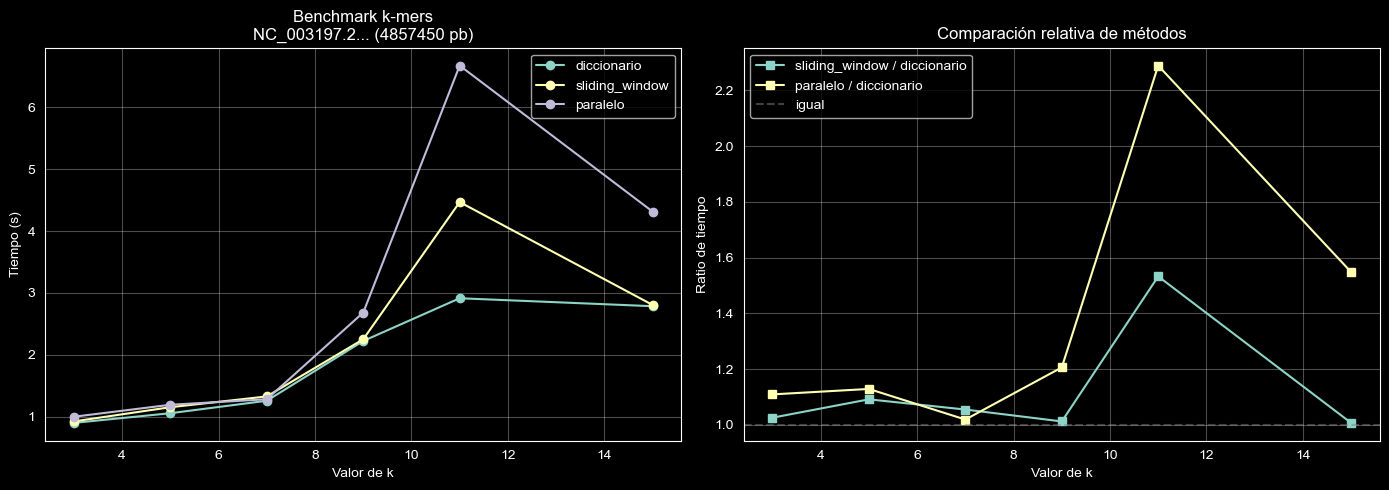

Estadísticas del benchmarking:

DICCIONARIO:
  Tiempo mínimo: 0.903121 s
  Tiempo máximo: 2.914671 s
  Tiempo promedio: 1.857966 s
  Desviación estándar: 0.818606 s

SLIDING_WINDOW:
  Tiempo mínimo: 0.926585 s
  Tiempo máximo: 4.467027 s
  Tiempo promedio: 2.156483 s
  Desviación estándar: 1.222588 s

PARALELO:
  Tiempo mínimo: 1.002021 s
  Tiempo máximo: 6.670231 s
  Tiempo promedio: 2.858279 s
  Desviación estándar: 2.056233 s



In [13]:
print("Iniciamos benchmarking de metodos de conteo de k-mers...")

secuencia_benchmark = secuencias["NC_003197.2"]
valores_k = [3, 5, 7, 9, 11, 15]
metodos = ["diccionario", "sliding_window", "paralelo"]

resultados_benchmark = {metodo: [] for metodo in metodos}
resumen_benchmark = []

for k in valores_k:
    print(f"Testando k={k}...")
    counter = KmerCounter(secuencia=secuencia_benchmark)
    referencia = None
    for metodo in metodos:
        inicio = time.perf_counter()
        resultado = counter.contar_kmers(k=k, metodo=metodo)
        tiempo_transcurrido = time.perf_counter() - inicio
        resultados_benchmark[metodo].append(tiempo_transcurrido)
        print(f"  {metodo}: {tiempo_transcurrido:.6f} segundos | únicos={len(resultado)}")
        if referencia is None:
            referencia = len(resultado)
        elif len(resultado) != referencia:
            print(f"  [Aviso] resultados distintos para k={k} con {metodo}")
    resumen_benchmark.append({"k": k, **{m: resultados_benchmark[m][-1] for m in metodos}})

print("\nBenchmarking completado.\n")

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
for metodo in metodos:
    plt.plot(valores_k, resultados_benchmark[metodo], marker='o', label=metodo)
plt.xlabel("Valor de k")
plt.ylabel("Tiempo (s)")
plt.title(f"Benchmark k-mers\n{secuencia_benchmark.id[:20]}... ({secuencia_benchmark.longitud} pb)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
for metodo in ["sliding_window", "paralelo"]:
    ratio = [resultados_benchmark[metodo][i] / resultados_benchmark["diccionario"][i] for i in range(len(valores_k))]
    plt.plot(valores_k, ratio, marker='s', label=f'{metodo} / diccionario')
plt.axhline(y=1, color='gray', linestyle='--', alpha=0.5, label='igual')
plt.xlabel("Valor de k")
plt.ylabel("Ratio de tiempo")
plt.title("Comparación relativa de métodos")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Estadísticas del benchmarking:\n")
for metodo in metodos:
    tiempos = resultados_benchmark[metodo]
    print(f"{metodo.upper()}:")
    print(f"  Tiempo mínimo: {min(tiempos):.6f} s")
    print(f"  Tiempo máximo: {max(tiempos):.6f} s")
    print(f"  Tiempo promedio: {np.mean(tiempos):.6f} s")
    print(f"  Desviación estándar: {np.std(tiempos):.6f} s")
    print()


In [14]:
def top_kmers_por_secuencia(diccionario_kmers: dict[str, int], top_n: int = 20) -> pd.DataFrame:
    ordenados = sorted(diccionario_kmers.items(), key=lambda x: x[1], reverse=True)[:top_n]
    return pd.DataFrame(ordenados, columns=["kmer", "frecuencia"])

def graficar_top_kmers(diccionario_kmers: dict[str, int], titulo: str, top_n: int = 20):
    df = top_kmers_por_secuencia(diccionario_kmers, top_n=top_n)
    plt.figure(figsize=(12, 5))
    plt.bar(df["kmer"], df["frecuencia"], color="#4C78A8")
    plt.xticks(rotation=90)
    plt.title(titulo)
    plt.xlabel("k-mer")
    plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()

def graficar_histograma(diccionario_kmers: dict[str, int], titulo: str):
    frecuencias = list(diccionario_kmers.values())
    plt.figure(figsize=(10, 5))
    plt.hist(frecuencias, bins=30, color="#F58518", edgecolor="black")
    plt.yscale("log")
    plt.title(titulo)
    plt.xlabel("Frecuencia del k-mer")
    plt.ylabel("Número de k-mers (escala log)")
    plt.tight_layout()
    plt.show()

def generar_wordcloud(diccionario_kmers: dict[str, int], titulo: str):
    items = sorted(diccionario_kmers.items(), key=lambda x: x[1], reverse=True)[:80]
    plt.figure(figsize=(14, 7))
    ax = plt.gca()
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")
    rng = random.Random(42)
    for kmer, freq in items:
        size = 10 + 18 * (np.log1p(freq) / np.log1p(max(diccionario_kmers.values())))
        x = rng.uniform(0.05, 0.95)
        y = rng.uniform(0.05, 0.95)
        color = plt.get_cmap("viridis")(rng.random())
        ax.text(x, y, kmer, fontsize=size, color=color, ha="center", va="center", transform=ax.transAxes)
    plt.title(titulo)
    plt.tight_layout()
    plt.show()


Visualizaciones Top k-mers


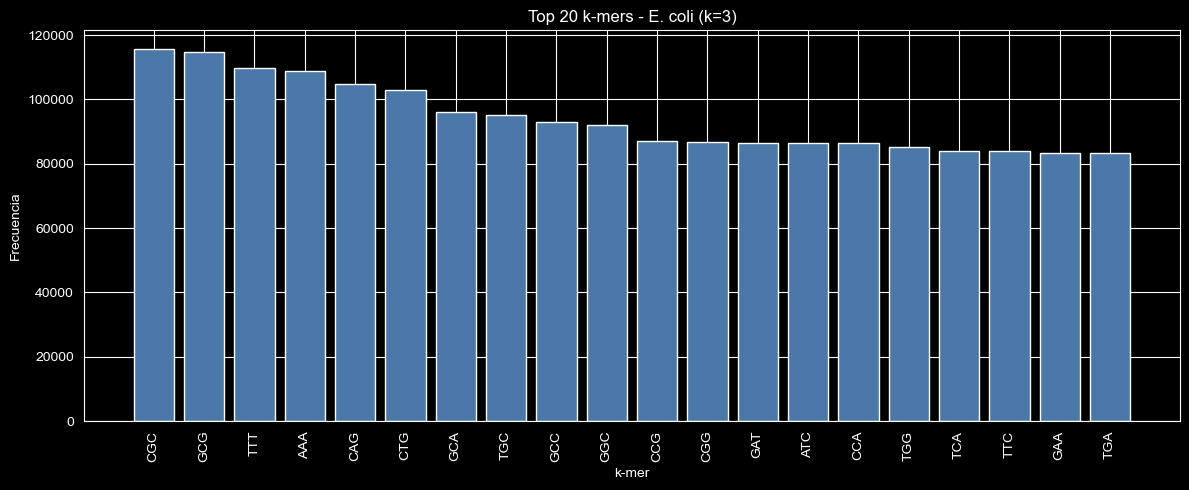

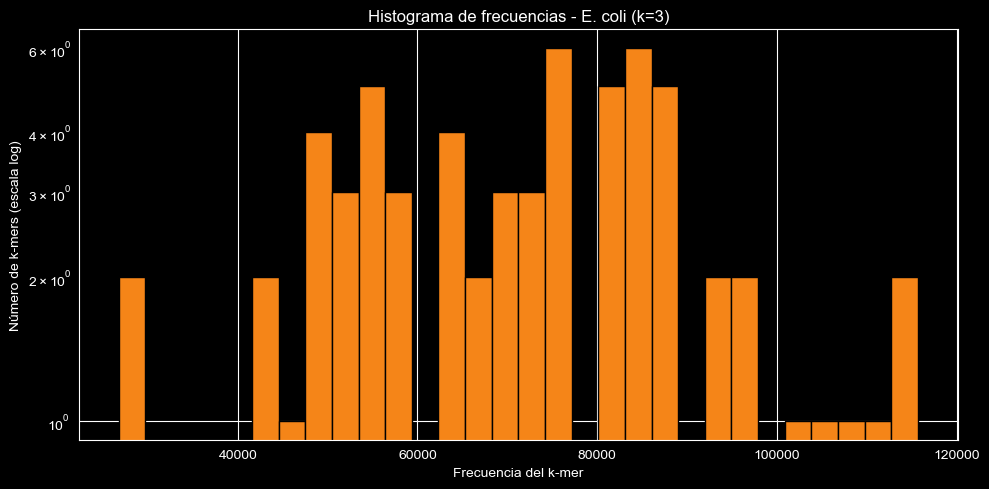

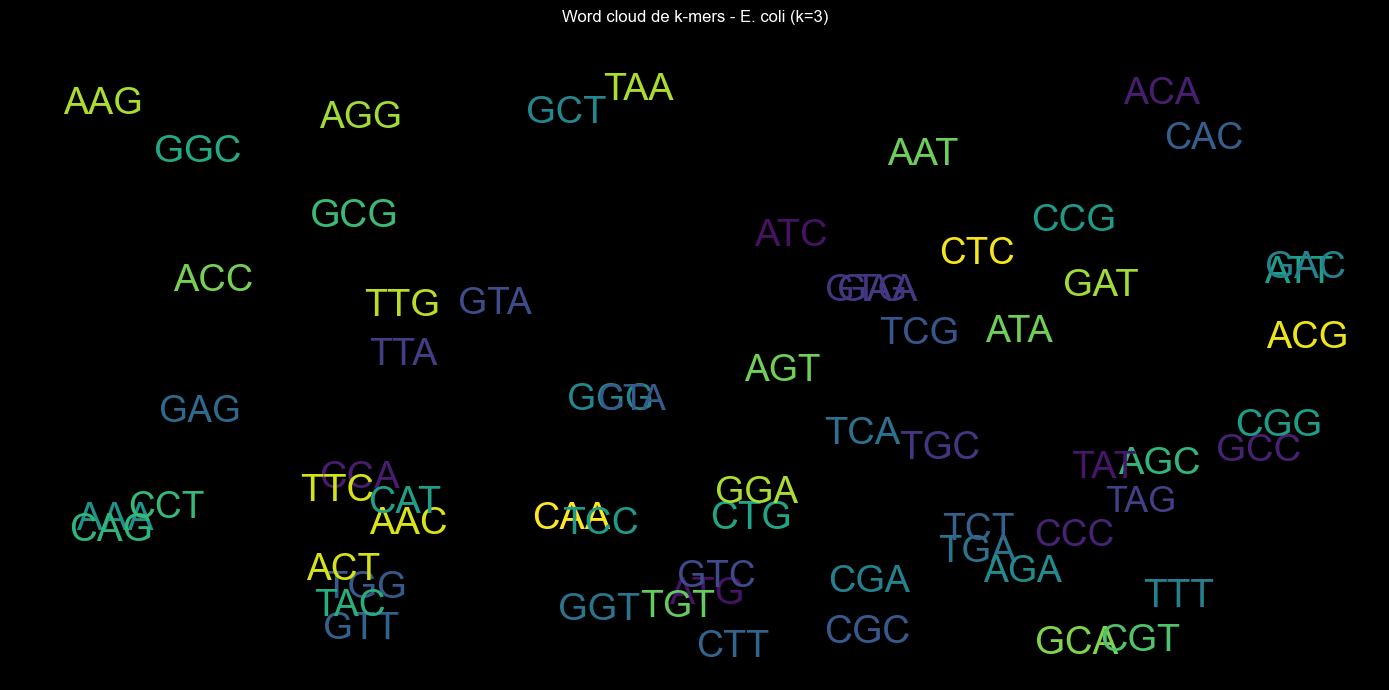

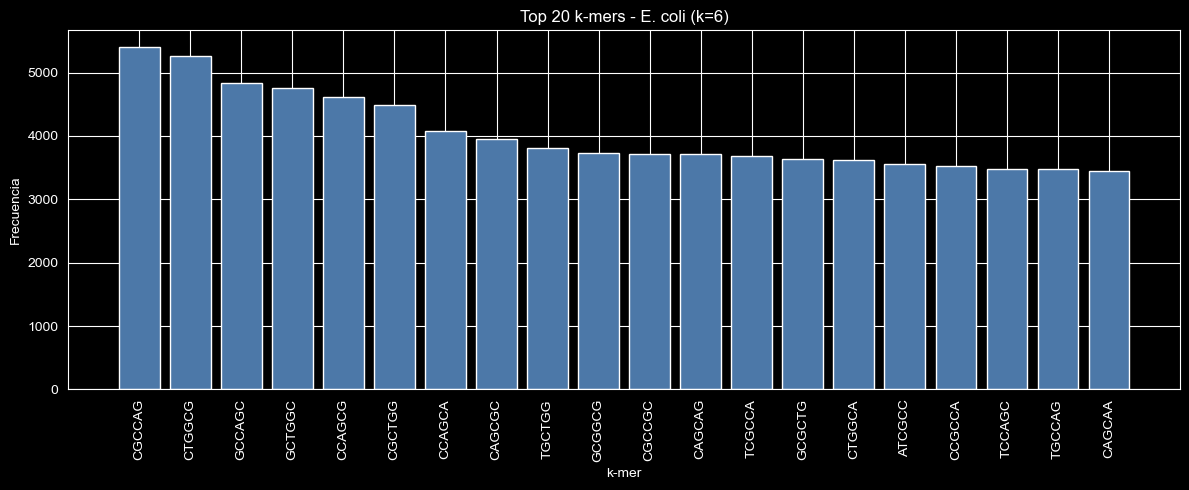

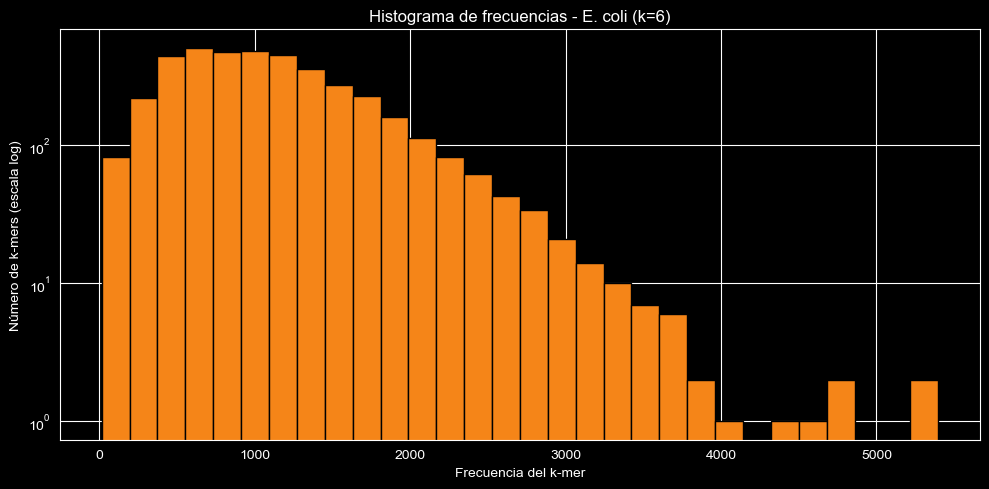

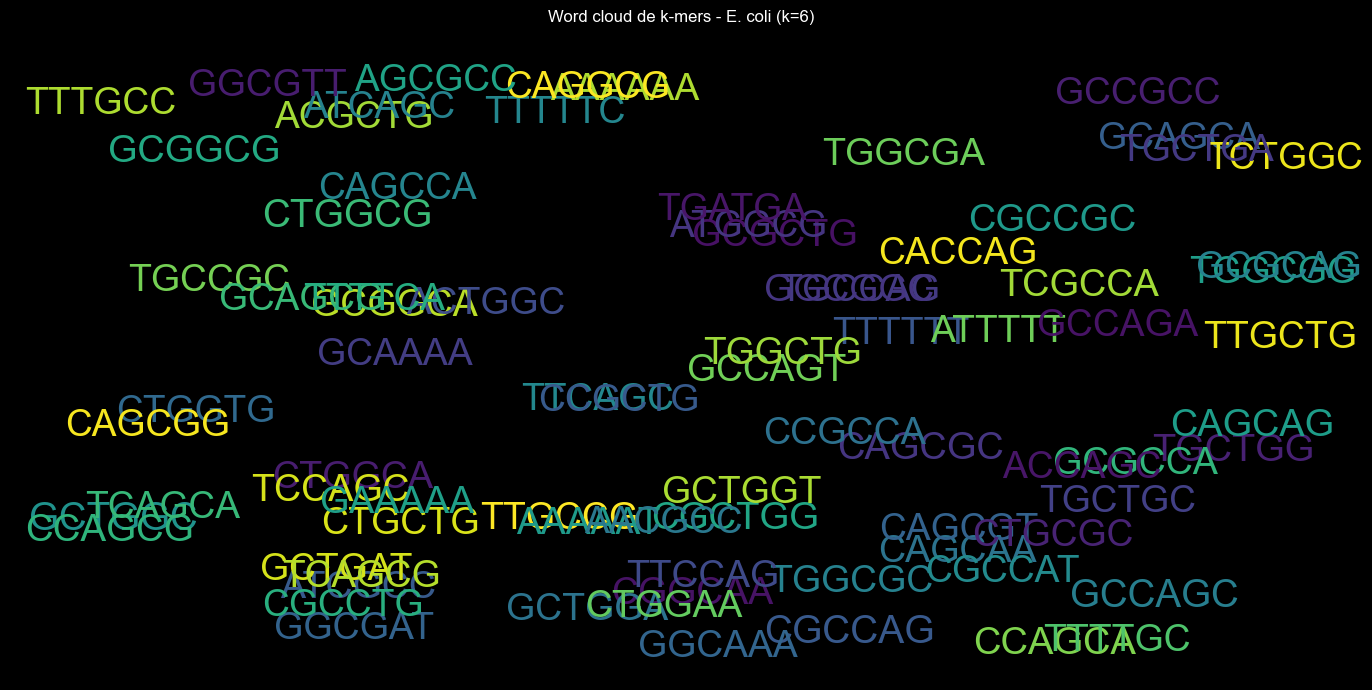

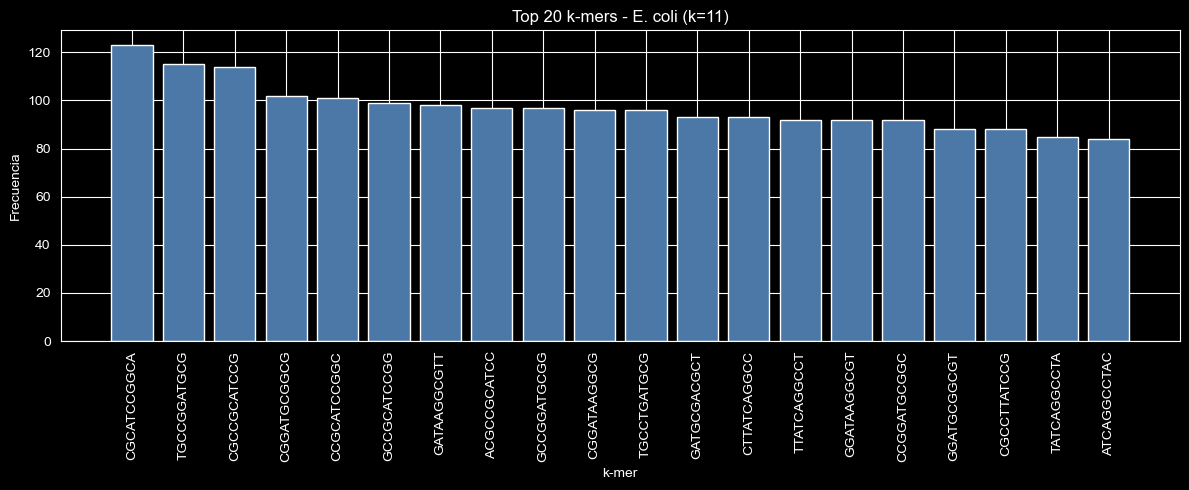

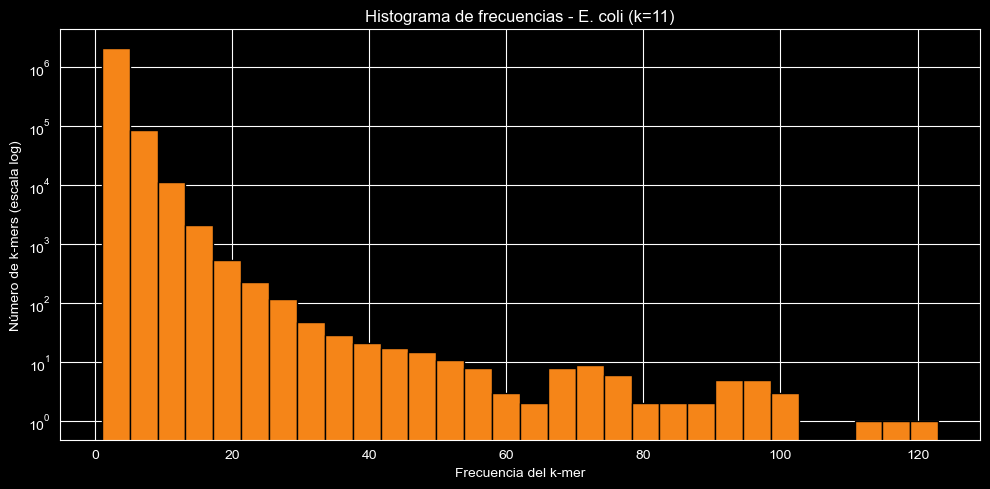

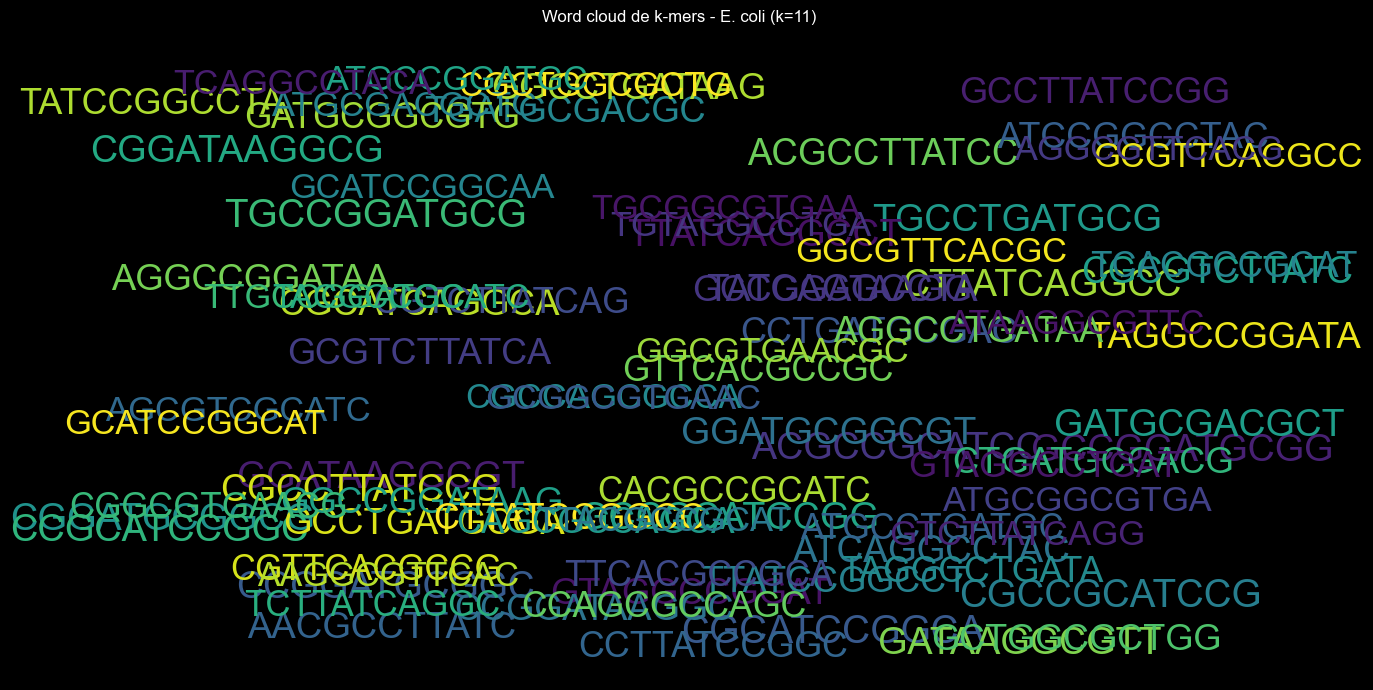

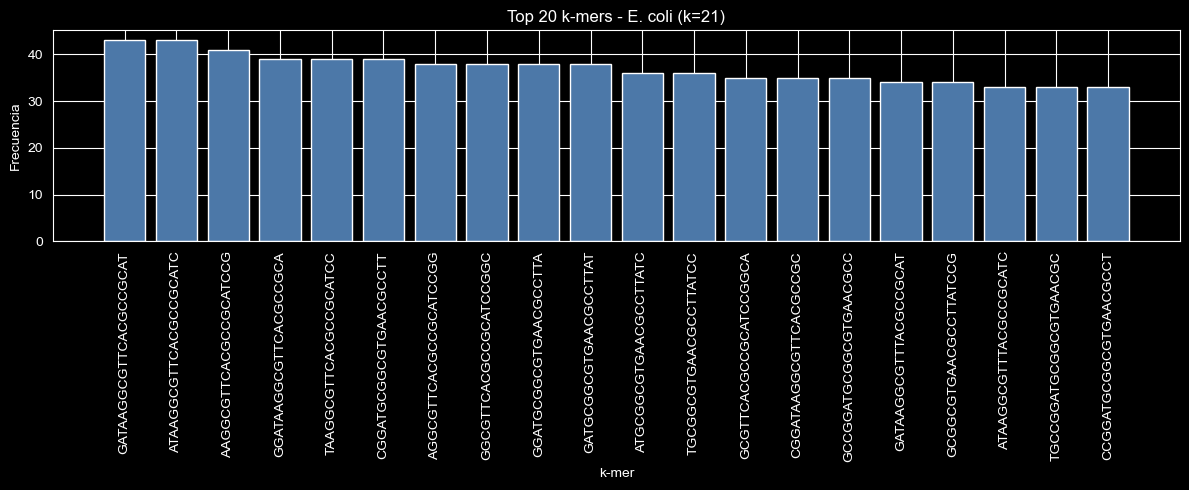

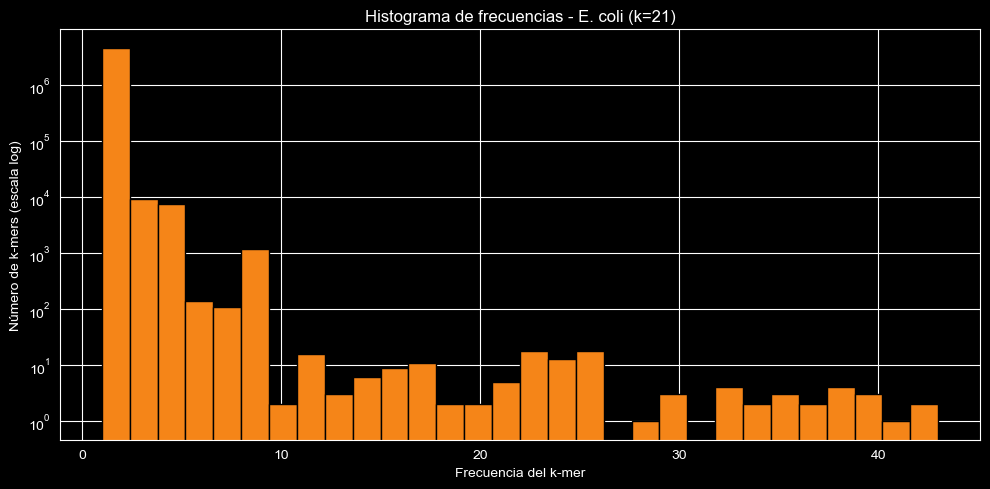

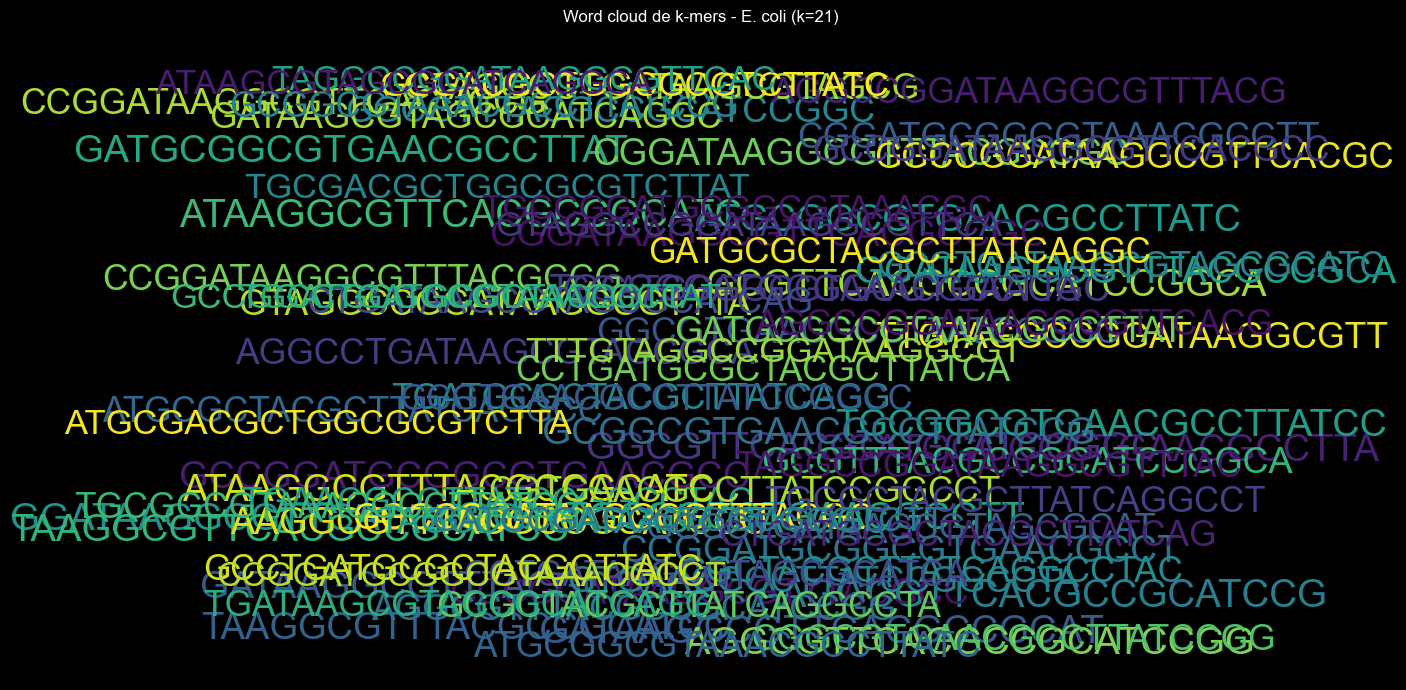

In [15]:
print("Visualizaciones Top k-mers")

K = [3, 6, 11, 21]

for k in K:
    kmers_top_visualizacion = total_frecuencias_kmers_analizadas[k]["NC_000913.2"]
    graficar_top_kmers(kmers_top_visualizacion, f"Top 20 k-mers - E. coli (k={k})", top_n=20)
    graficar_histograma(kmers_top_visualizacion, f"Histograma de frecuencias - E. coli (k={k})")
    generar_wordcloud(kmers_top_visualizacion, f"Word cloud de k-mers - E. coli (k={k})")

Comparación E. coli vs Salmonella
                   Métrica   Valor
0        k-mer compartidos  4096.0
1     k-mer únicos E. coli     0.0
2  k-mer únicos Salmonella     0.0
3                  Jaccard     1.0


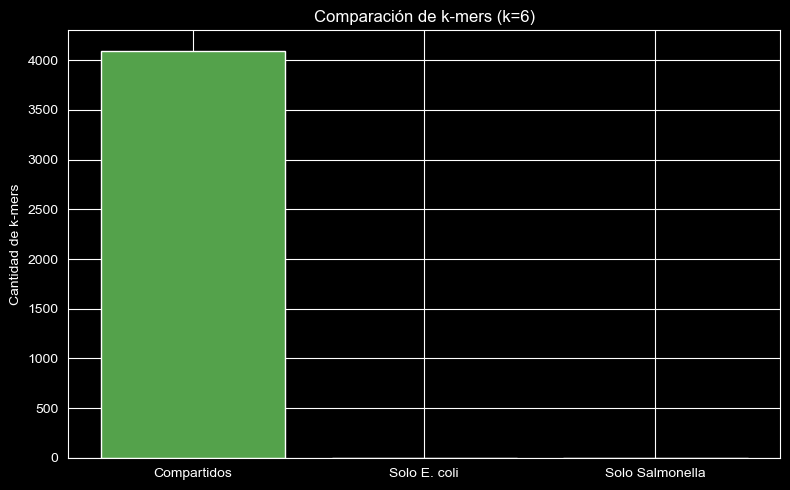

In [16]:
print("Comparación E. coli vs Salmonella")
k_comparacion = 6
kmers_ecoli = set(total_frecuencias_kmers_analizadas[k_comparacion]["NC_000913.2"].keys())
kmers_salmonella = set(total_frecuencias_kmers_analizadas[k_comparacion]["NC_003197.2"].keys())

interseccion = kmers_ecoli & kmers_salmonella
union = kmers_ecoli | kmers_salmonella
solo_ecoli = kmers_ecoli - kmers_salmonella
solo_salmonella = kmers_salmonella - kmers_ecoli
jaccard = len(interseccion) / len(union) if union else 0

resumen_comparacion = pd.DataFrame([
    {"Métrica": "k-mer compartidos", "Valor": len(interseccion)},
    {"Métrica": "k-mer únicos E. coli", "Valor": len(solo_ecoli)},
    {"Métrica": "k-mer únicos Salmonella", "Valor": len(solo_salmonella)},
    {"Métrica": "Jaccard", "Valor": round(jaccard, 4)},
])
print(resumen_comparacion)

plt.figure(figsize=(8, 5))
plt.bar(["Compartidos", "Solo E. coli", "Solo Salmonella"], [len(interseccion), len(solo_ecoli), len(solo_salmonella)], color=["#54A24B", "#4C78A8", "#E45756"])
plt.title(f"Comparación de k-mers (k={k_comparacion})")
plt.ylabel("Cantidad de k-mers")
plt.tight_layout()
plt.show()


Comparación E. coli vs Salmonella

===== k = 3 =====
                   Métrica  Valor
0        k-mer compartidos   64.0
1     k-mer únicos E. coli    0.0
2  k-mer únicos Salmonella    0.0
3                  Jaccard    1.0


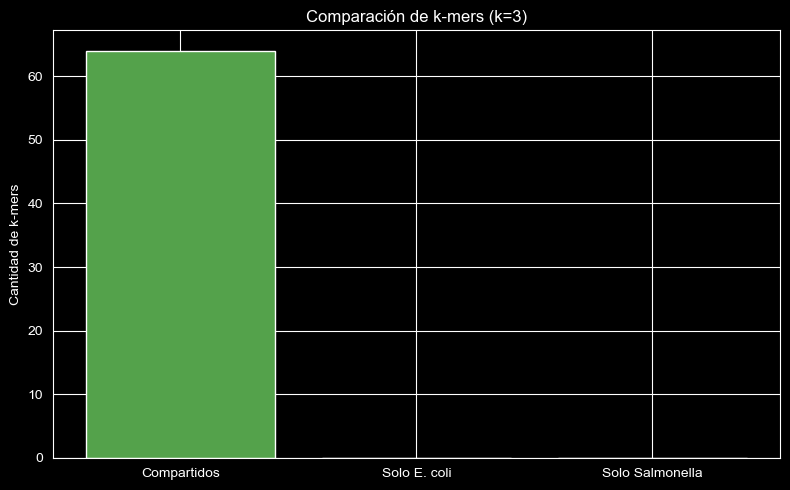


===== k = 6 =====
                   Métrica   Valor
0        k-mer compartidos  4096.0
1     k-mer únicos E. coli     0.0
2  k-mer únicos Salmonella     0.0
3                  Jaccard     1.0


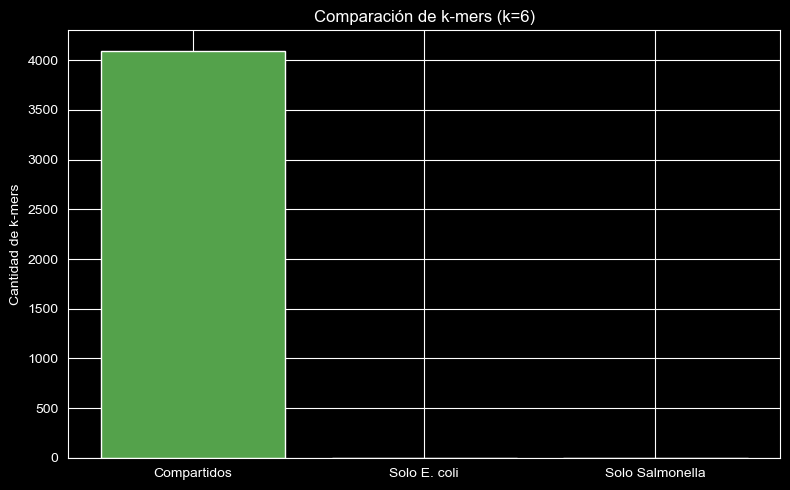


===== k = 11 =====
                   Métrica         Valor
0        k-mer compartidos  1.502853e+06
1     k-mer únicos E. coli  6.939820e+05
2  k-mer únicos Salmonella  7.344910e+05
3                  Jaccard  5.127000e-01


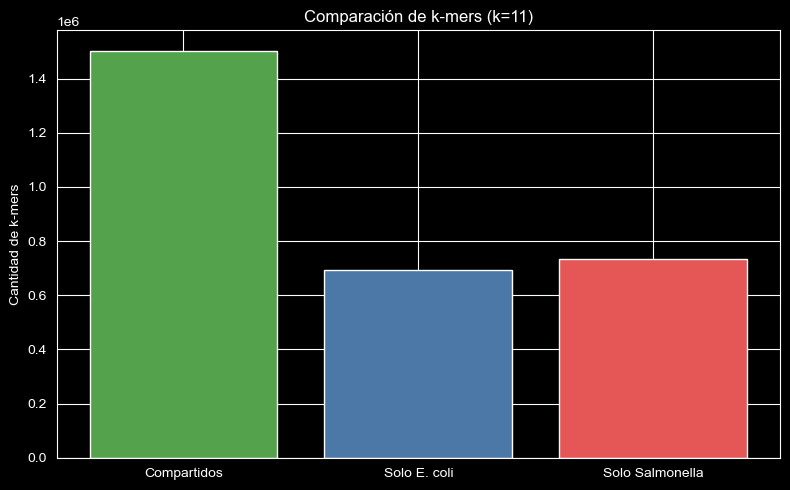


===== k = 21 =====
                   Métrica        Valor
0        k-mer compartidos   147642.000
1     k-mer únicos E. coli  4414858.000
2  k-mer únicos Salmonella  4660053.000
3                  Jaccard        0.016


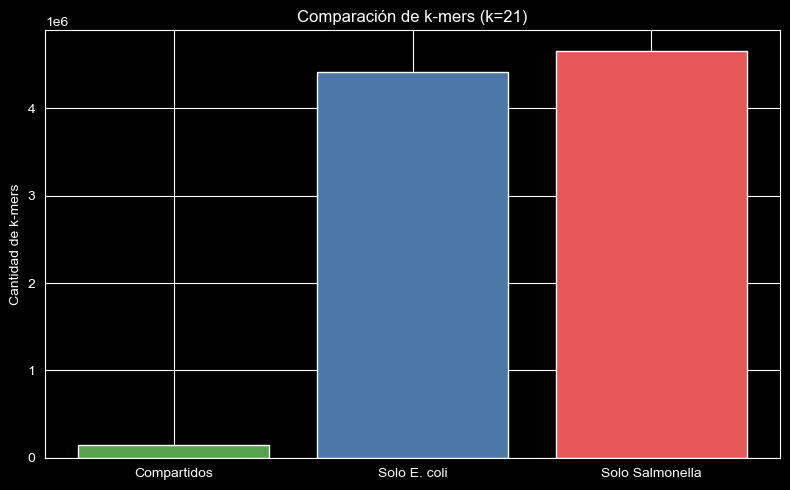

In [17]:
print("Comparación E. coli vs Salmonella")

K = [3, 6, 11, 21]

for k_comparacion in K:

    kmers_ecoli = set(
        total_frecuencias_kmers_analizadas[k_comparacion]["NC_000913.2"].keys()
    )

    kmers_salmonella = set(
        total_frecuencias_kmers_analizadas[k_comparacion]["NC_003197.2"].keys()
    )

    interseccion = kmers_ecoli & kmers_salmonella
    union = kmers_ecoli | kmers_salmonella

    solo_ecoli = kmers_ecoli - kmers_salmonella
    solo_salmonella = kmers_salmonella - kmers_ecoli

    jaccard = len(interseccion) / len(union) if union else 0

    resumen_comparacion = pd.DataFrame([
        {"Métrica": "k-mer compartidos", "Valor": len(interseccion)},
        {"Métrica": "k-mer únicos E. coli", "Valor": len(solo_ecoli)},
        {"Métrica": "k-mer únicos Salmonella", "Valor": len(solo_salmonella)},
        {"Métrica": "Jaccard", "Valor": round(jaccard, 4)},
    ])

    print(f"\n===== k = {k_comparacion} =====")
    print(resumen_comparacion)

    plt.figure(figsize=(8, 5))

    plt.bar(
        ["Compartidos", "Solo E. coli", "Solo Salmonella"],
        [len(interseccion), len(solo_ecoli), len(solo_salmonella)],
        color=["#54A24B", "#4C78A8", "#E45756"]
    )

    plt.title(f"Comparación de k-mers (k={k_comparacion})")
    plt.ylabel("Cantidad de k-mers")

    plt.tight_layout()
    plt.show()


## 5. Conclusiones
- El conteo con diccionario es la base más estable y simple para el laboratorio.
- El método paralelo queda como opción avanzada, pero en Jupyter/Windows puede no superar al secuencial por el overhead.
- Las visualizaciones permiten identificar abundancias y dispersión de k-mers.
- La comparación entre E. coli y Salmonella muestra similitudes y diferencias genómicas medibles con Jaccard y k-mers exclusivos.

